<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/recitations/09_ImageProcessingRecitation_CannyEdgeDetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.signal import convolve

In [7]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(fname:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        fname: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, fname)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [8]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

<div dir="rtl">

# 9. Edge Detection (גילוי שפה)

<dir>

<div dir="rtl">

## 9.1 שפה (קצוות):

<dir>

<div dir="rtl">

Edge (שפה / קצה) הוא מקום בתמונה שבו יש שינוי חד בעוצמת האפור. לדוגמא:

* מעבר מרקע כהה לעצם בהיר

* גבול של עצם בתמונה

* קצה של צורה (עיגול, מלבן, בניין וכו׳)

המשימה המרכזית שלנו היא זיהוי עצמים.

בתרגול הבא נדון בזיהוי קווים ומעגלים (Hough Transform).

בתרגול הזה נציג את אלגוריתם Canny לגילוי שפות.

<dir>

<div dir="rtl">

כיצד ניתן לאתר את פיקסלי השפה?

 באמצעות גרדיאנט.
<dir>

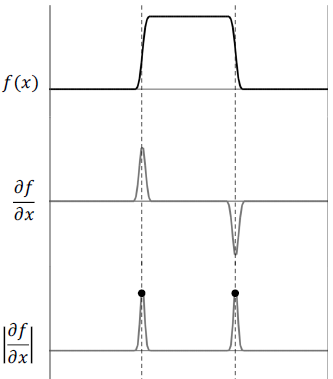

<div dir="rtl">

בתמונה דו-ממדית:
<dir>

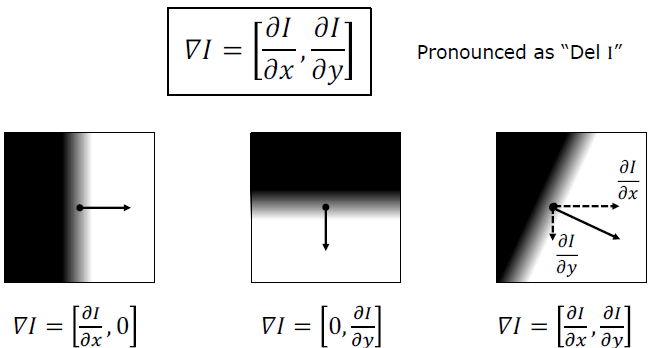

<div dir="rtl">

למה צריך לעבור לערך מוחלט של נגזרת?

<dir>

<div dir="rtl">

### 9.1.1 גרדיאנט:

<dir>

<div dir="rtl">

**בתחום הרציף:**


$S_x=\frac{f(x+\Delta x,y)-f(x,y)}{\Delta x}$

$S_y=\frac{f(x,y+\Delta y)-f(x,y)}{\Delta y}$




<div dir="rtl">

**בתחום הבדיד** נעשה קירוב של הנגזרת ע"י קונבולוציה:

<dir>


$S_x=I(x+1,y)-I(x,y)$=`convolve(img, np.array([[1,-1]]), 'same')`


$S_y=I(x,y+1)-I(x,y)$=`convolve(img, np.array([[1,-1]]).T, 'same')`



<div dir="rtl">

וקטור הגרדיאנט:

* עוצמת השינוי
* כיוון השינוי

<dir>

$\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)$

<div dir="rtl">

עוצמת המגניטודה של גרדיאנט בפיקסל אחד:

<dir>

$S=\sqrt{S_x^2+S_y^2}$

<div dir="rtl">

כיוון הגרדיאנט של פיקסל אחד:

<dir>


$$tg\space\theta=\frac{S_y}{S_x}$$

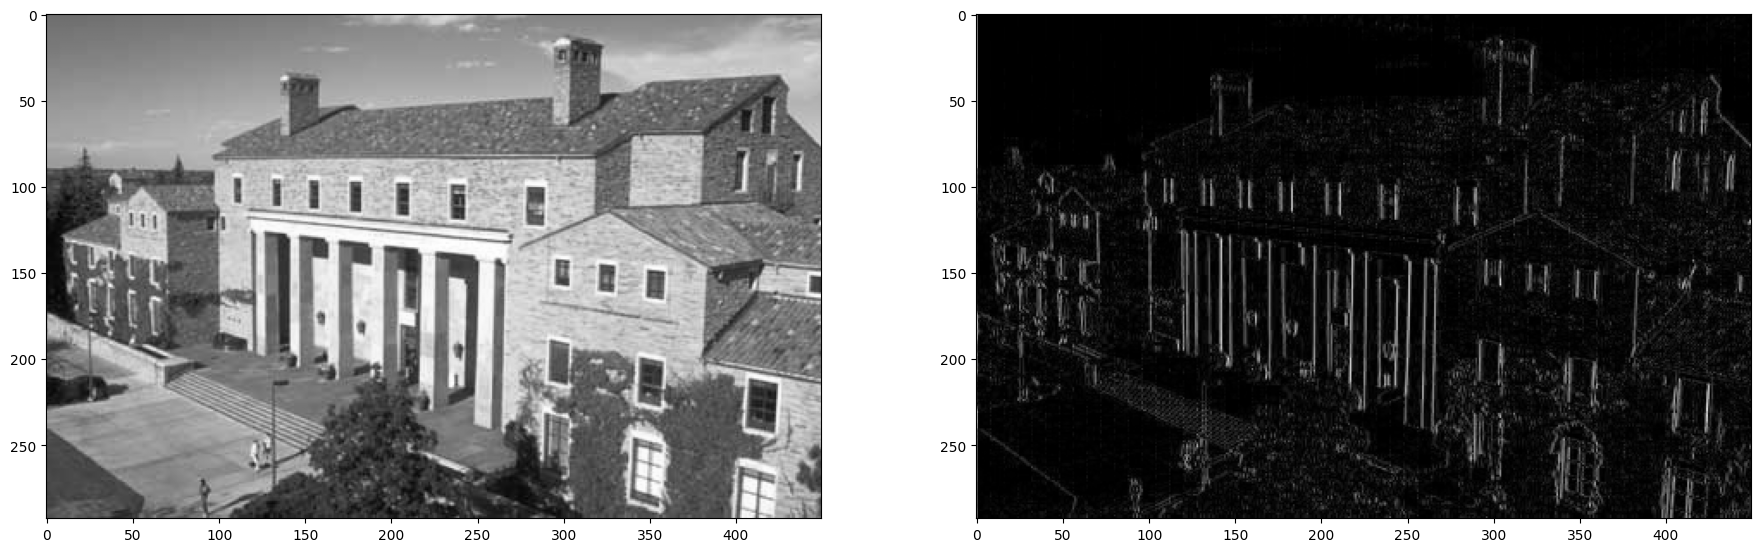

In [9]:
img = read_file(fname='house.tiff') / 255
Sx = convolve(img, np.array([[1,-1]]), 'same')
plot_images(img, np.clip(abs(Sx), a_min=0, a_max=1))

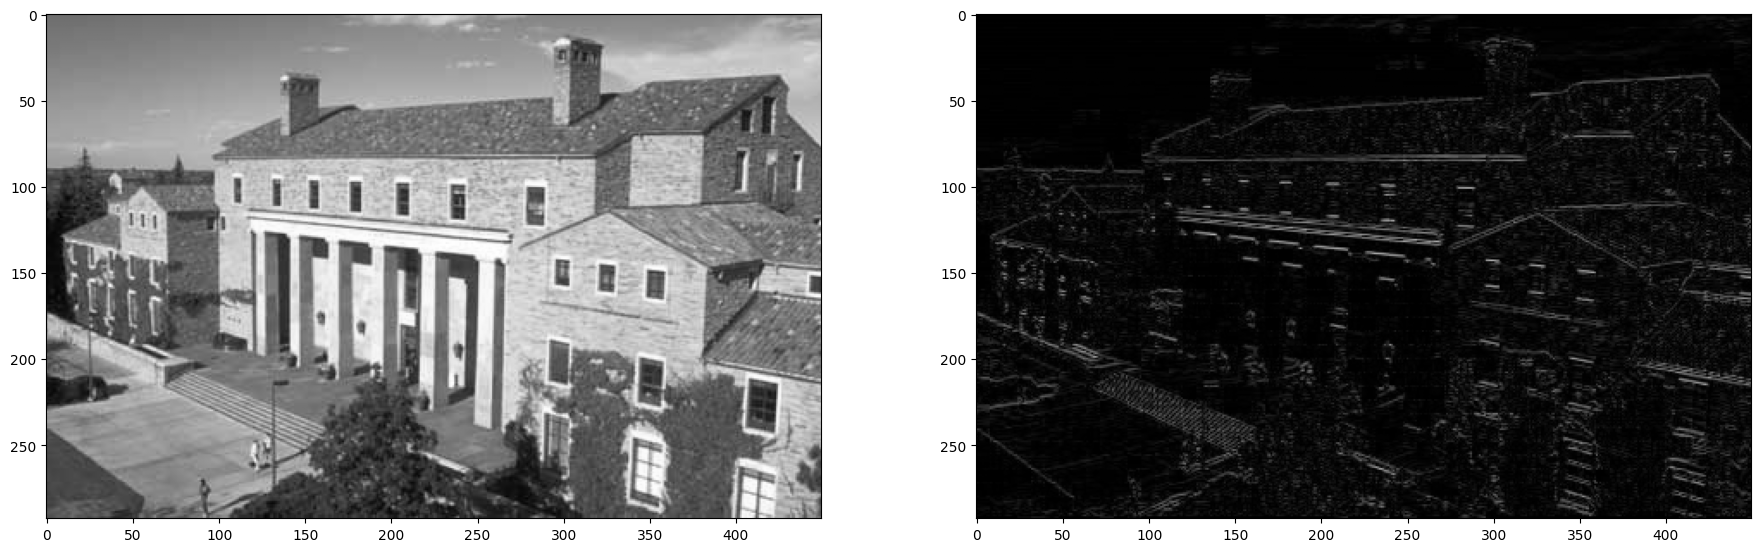

In [10]:
img = read_file(fname='house.tiff') / 255
Sy = convolve(img, np.array([[1,-1]]).T, 'same')
plot_images(img, np.clip(abs(Sy), a_min=0, a_max=1))

<div dir="rtl">

## 9.2 דרישות מגלאי קצוות טוב:

1. **זיהוי אמיתי:** כל רעש קטן יכול ליצור קצה ולכן נדרוש מינימום False Positive ומינימום False Negative
2. **מיקום מדוייק:** הפיקסל שמסומן כקצה צריך להיות קרוב ככל האפשר למיקום האמיתי של הקצה בתמונה.
* החלקה מזיזה קצוות
* קצה יכול להימרח על כמה פיקסלים
3. **תגובה בודדת:** רוחב הקצה צריך להיות פיקסל 1

<dir>

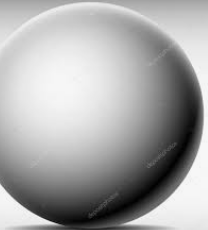

<div dir="rtl">

**שימו לב:**

 ייתכן שלא תתקבל תגובה יחידה, למשל באזורים מוצללים, כמו כדורים מוארים, ובאזורים עם רעש.
<dir>


<div dir="rtl">

## 9.3 אלגוריתם Canny edge detector:
1. ביצוע החלקה
2. חישוב גרדיאנט
3. חישוב מגניטודה וכיוון הגרדיאנט
4. תגובה בודדת לקצה - רוחב פיקסל 1
5. טיפול בהיסטרזיה
<dir>


<div dir="rtl">

### 9.2.3 החלקה/ הפחתת רעש:

פעולת זיהוי הקצוות רגישה לרעש, אלגוריתם Canny משתמש במסנן גאוסי כדי להסיר רעש גאוסיאני מהתמונה:
<dir>

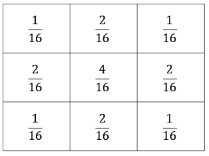

**Step 1: Smooth the image with a filter:**
```python
use a Gauss filter:
    1 2 1
    2 4 2  / 16
    1 2 1
input: img
output: img_s
```


<div dir="rtl">

### 9.3.2 מטריצת הגרדיאנט:
1. יצירת מטירצת גרדיאנט לכל ציר ע"י קונבולציה
2. $S=\sqrt{S_x^2+S_y^2}$ - חישוב המגניטודה של כל פיקסל בשני הכיוונים (חיבור וקטורי)
<dir>

**Step 2: create S (gradients matrix) and tg_theta (grad angles)**
```python
input: img_s

Sx = convolve(img_s, np.array([[1, -1]]), 'same')
Sy = convolve(img_s, np.array([[1, -1]]).T, 'same')
S = np.sqrt(Sx*Sx + Sy*Sy)
```

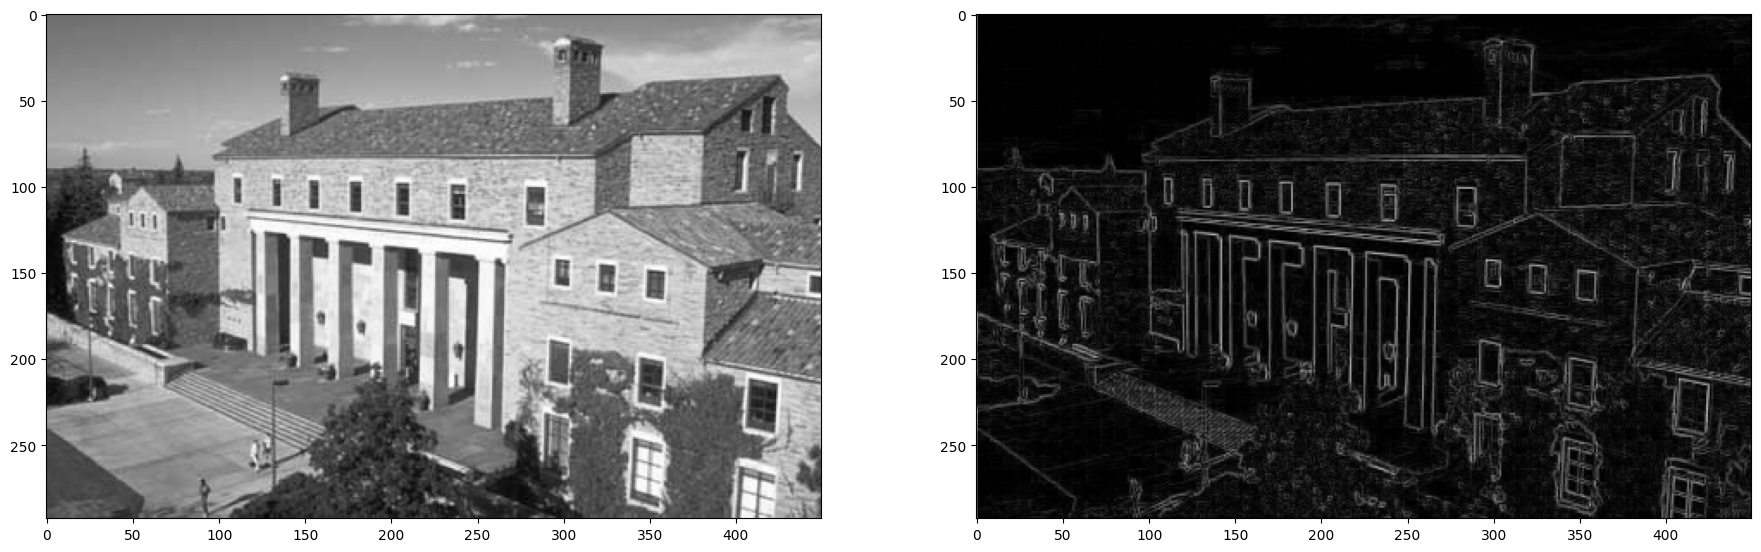

In [11]:
S = np.sqrt(Sx*Sx + Sy*Sy)
plot_images(img, S)


<div dir="rtl">

### 9.3.3 חישוב כיוון הגרדיאנט:

מציאת כיוון הגרדיאנט של כל פיקסל לפי חלוקה ל4 הרבעים של מעגל היחידה,
 על מנת לספק את דרישת התגובה הבודדת, נבחר רק פיקסל קצה אחד בכיוון השיפוע, המחושב על ידי:

$$tg\space\theta=\frac{S_y}{S_x}$$


<dir>

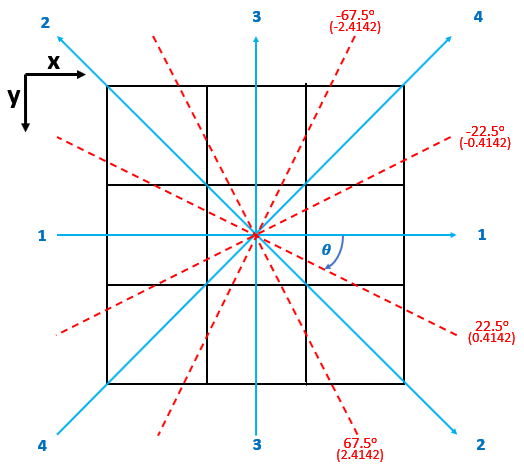



<div dir="rtl">

נגדיר את 4 הכיוונים העיקריים על ידי:

 $1: -0.4142 <=tg\space\theta <=0.4142$

$2: 0.4142 <=tg\space\theta <=2.4142$

$3: |tg\space\theta| >2.4142$

$4: -2.4142 <=tg\space\theta <=0.4142$

<dir>

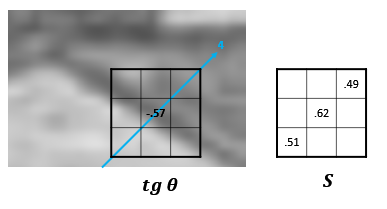

<div dir="rtl">

האלגוריתם:

1. יצירת מטריצה `tg_theta = Sy / Sx` **שימו לב** לא לחלק ב0.
2. יצירת מטריצה `grad_dir` ע"י חלוקה ל4 רבעים לפי התנאים.

<dir>

**Step 3: compute the grad main directions (1..4)**
```python
Sx[Sx==0] = 0.0001 #to avoid zero division
tg_theta = Sy / Sx    # create matrix of grad angles
create grad_dir - matrix with size of img, filled with zeros
scan tg_theta:
    if -0.4142 <= tg_theta[r, c] <= 0.4142: grad_dir[r, c] = 1
    if  0.4142 <  tg_theta[r, c] <= 2.4142: grad_dir[r, c] = 2
    if        abs(tg_theta[r, c]) > 2.4142: grad_dir[r, c] = 3
    if -2.4142 <= tg_theta[r, c] < -0.4142: grad_dir[r, c] = 4
```

<div dir="rtl">

### 9.4 Non Maximum Suppression (NMS):

המטרה: קצוות עבים ייהפכו לפיקסל בודד.

האלגוריתם:
1. מעבר על כל הפיקסלים במטריצת `img_e` , אם הפיקסל הוא 0 ממשיכים.
2. מתוך מטריצת `grad_dir` בודקים לאיזה קבוצה הוא שייך.
3. בדיקת מקסימום מקומי ביחס לשני השכנים הרלוונטים.

<dir>

**Step 4: Non Max Suppress (NMS):**
```python
scan img_e:
    if img_e[r, c] == 0: continue
    if grad_dir[r, c] == 1:
        if S[r, c] < max(S[r  ,c-1], S[r  ,c+1]): img_e[r, c] = 0
    if grad_dir[r, c] == 2:
        if S[r, c] < max(S[r-1,c-1], S[r+1,c+1]): img_e[r, c] = 0
    if grad_dir[r, c] == 3:
        if S[r, c] < max(S[r-1,c  ], S[r+1,c  ]): img_e[r, c] = 0
    if grad_dir[r, j] == 4
        if S[r, c] < max(S[r-1,c+1], S[r+1,c-1]): img_e[r, c] = 0
```

<div dir="rtl">


<dir>


<div dir="rtl">

### 9.3.5 סף היסטרזיס (עם מעבר כפול):

לאחר שיש לנו את כל הנתונים על הפיקסלים - נבחר סף.

קשה לזהות גם FP וגם FN ע"י סף אחד:
* סף גבוה מידי - FN  גבוה, איבוד של קצוות חלשים.
* סף נמוך מידי - FN גבוה, רעשים יזהו כקצה.

לכן נחלק את הפיקסלים ל3 קצוות לפי 2 הספים הבאים `t_high` `t_low`:
* כל פיקסל שגבוה מ`t_high` יסווג כקצה בטוח.
* כל פיקסל שנמוך מ`t_low` יסווג כלא קצה.
* הפיקסלים שבין `t_high` ו`t_low` יסווגו כקצה רק אם הם מחוברים לפיקסל קצה בטוח.

**האלגוריתם:**
1. קביעת `t_high` ו`t_low`
2. יצירת מטריצה `img_e`
3. מעבר ראשון על המטריצה `img_e` לבדיקת הסף לפי המקרים הבאים:
 - case `S[r,c] < t_low: img_e[r,c] = 0`
 - case `S[r,c] > t_high: img_e[r,c] = 1`
 - case `t_low <= S[r,c] <= t_high and any img_e[r-1:r+2, c-1,c+2]==1: img_e[r,c] = 1` - אם הפיקסל בין הספים, נבדוק את 8 השכנים ואם לפחות 1 מוגדר כקצה כלומר 1 הפיקסל כך יסווג ל1.
4. מעבר שני על מטריצת `img_e` עם סריקה בכיוון ההפוך - אם פיקסל מחובר לקצה אבל הוא נסרק לפני שבקנו את הקצה.


<dir>

**Step 5: thresholding**
```python
create img_e - edges matrix with size of img, filled with zeros
```

**Step 5.1: pass 1: from top-left to bottom-right:**
```python
scan S (without first and last rows and columns)
    if S[r,c] < t_low: img_e[r,c] = 0
    if S[r,c] > t_high:img_e[r,c] = 1
    else: img_e[r,j] = np.any(img_e[r-1:r+2, c-1:c+2])
```
**Step 5.2: pass 2: from bottom-right to top-left:**
```python
same as in 3.1 ...
```


##9.4 Canny Edge detector using OpenCV

In [12]:
img = read_file('balls4.tiff').astype('uint8')
import cv2

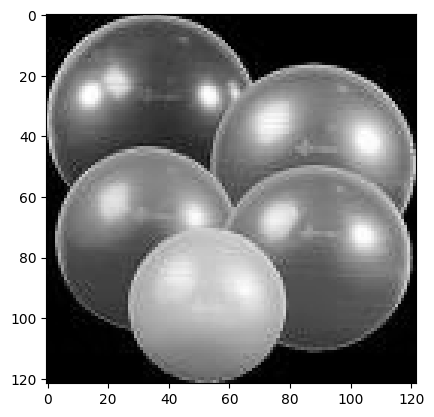

In [17]:
plt.imshow(img, cmap='gray');

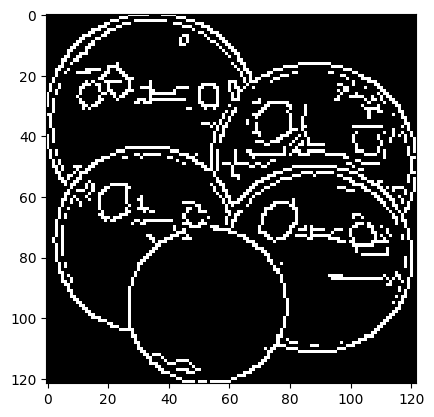

In [18]:
edges =cv2.Canny(image=img, threshold1=40, threshold2=140)
plt.imshow(edges, cmap='gray');

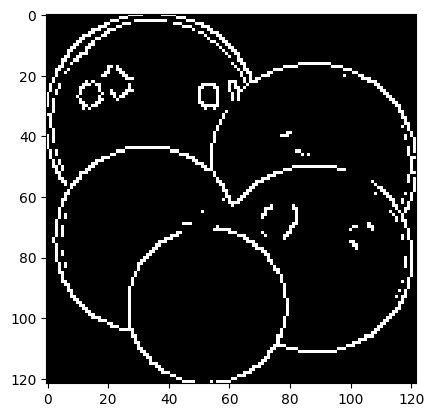

In [21]:
edges =cv2.Canny(image=img, threshold1=230, threshold2=240)
plt.imshow(edges, cmap='gray');

##9.5 Dynamic Plot

In [15]:
import plotly.express as px
fig = px.imshow(S, color_continuous_scale='gray')
fig.update_layout(coloraxis_showscale=False)